In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
data_path = r"C:\Users\user\Downloads\module_6\data\bbc"
categories = ['business', 'entertainment', 'politics', 'sport', 'tech']

def load_docs(category):

    folder = os.path.join(data_path, category)
    docs = []
    for file in os.listdir(folder):
        if file.endswith('.txt'):
            file_path = os.path.join(folder, file)
            content = None
            for enc in ['utf-8', 'cp1252', 'latin-1', 'ISO-8859-1']:
                try:
                    with open(file_path, 'r', encoding=enc) as f:
                        content = f.read().strip()
                    break
                except UnicodeDecodeError:
                    continue
            if content is None:
                print(f"Не удалось прочитать {file_path}")
                continue
            docs.append(content)
    return docs

corpus_by_cat = {cat: load_docs(cat) for cat in categories}

# Предобработка текста
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token not in stop_words and len(token) > 2]
    return tokens

processed_corpus = {}
for cat, docs in corpus_by_cat.items():
    processed_corpus[cat] = [preprocess(doc) for doc in docs]

In [ ]:
def train_lda_for_category(category, texts, num_topics=5, passes=10):
    dictionary = Dictionary(texts)
    dictionary.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dictionary.doc2bow(text) for text in texts]

    lda_model = LdaModel(corpus=corpus,
                         id2word=dictionary,
                         num_topics=num_topics,
                         passes=passes,
                         random_state=42)

    # Оценка когерентности
    coherence_model = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence = coherence_model.get_coherence()
    print(f"{category}: Coherence = {coherence:.3f}")

    # Распределение тем по документам
    topic_distributions = [lda_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]
    avg_topic_props = np.mean([[prob for _, prob in sorted(doc)] for doc in topic_distributions], axis=0)

    # Интерактивная визуализация pyLDAvis
    vis = gensimvis.prepare(lda_model, corpus, dictionary)
    #pyLDAvis.save_html(vis, f'lda_{category}.html')

    return lda_model, avg_topic_props, dictionary, corpus

results = {}
for cat in categories:
    print(f"\n=== Обработка категории: {cat} ===")
    texts = processed_corpus[cat]
    if len(texts) == 0:
        continue
    lda, avg_props, dictionary, corpus = train_lda_for_category(cat, texts, num_topics=5)
    results[cat] = {'model': lda, 'avg_props': avg_props, 'dictionary': dictionary, 'corpus': corpus}


=== Обработка категории: business ===
business: Coherence = 0.409

=== Обработка категории: entertainment ===
entertainment: Coherence = 0.375

=== Обработка категории: politics ===
politics: Coherence = 0.308

=== Обработка категории: sport ===
sport: Coherence = 0.406

=== Обработка категории: tech ===
tech: Coherence = 0.402


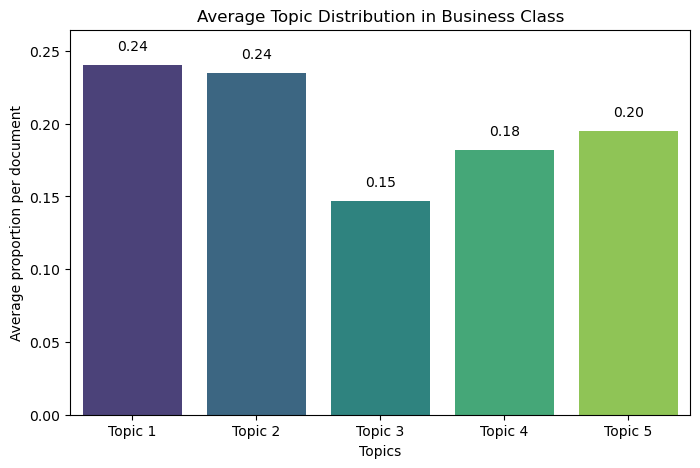

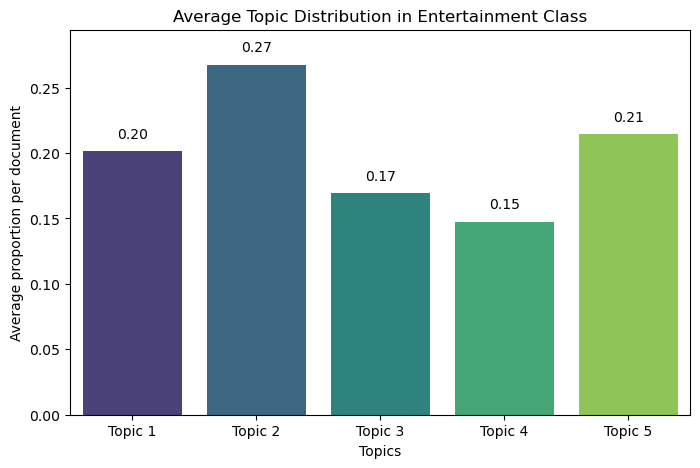

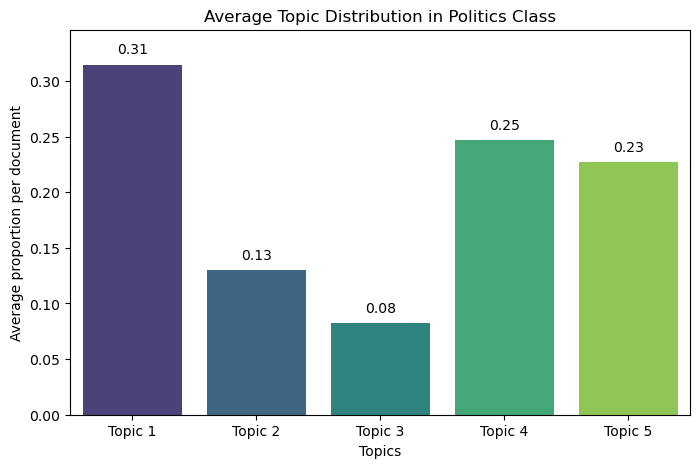

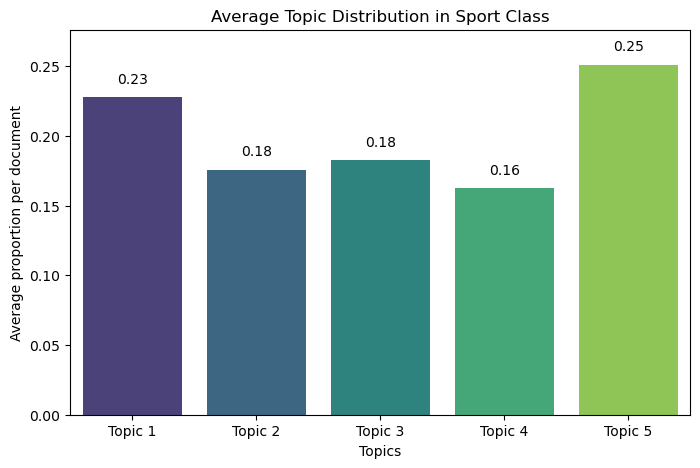

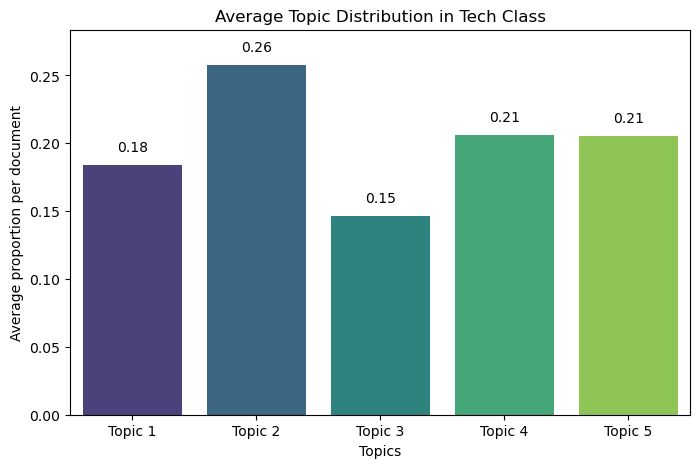

In [ ]:
for cat in categories:
    if cat not in results:
        continue
    avg_props = results[cat]['avg_props']
    topics = [f"Topic {i+1}" for i in range(len(avg_props))]
    plt.figure(figsize=(8,5))
    sns.barplot(x=topics, y=avg_props, palette='viridis')
    plt.title(f'Average Topic Distribution in {cat.capitalize()} Class')
    plt.ylabel('Average proportion per document')
    plt.xlabel('Topics')
    plt.ylim(0, max(avg_props)*1.1)
    for i, v in enumerate(avg_props):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
    plt.savefig(f'dist_{cat}.png')
    plt.show()


In [ ]:
categories

['business', 'entertainment', 'politics', 'sport', 'tech']

In [ ]:
#создаем интерактивную визуализацию для тематических моделей (LDA) для проведения анализа того, какие слова входят в темы и насколько эти темы уникальны.
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
from IPython.display import display, HTML

for cat, res in results.items():
    lda_model = res['model']
    corpus = res['corpus']
    dictionary = res['dictionary']

    vis = gensimvis.prepare(lda_model, corpus, dictionary)
    # Convert the prepared data to HTML and display it
    html_str = pyLDAvis.prepared_data_to_html(vis)
    display(HTML(html_str))

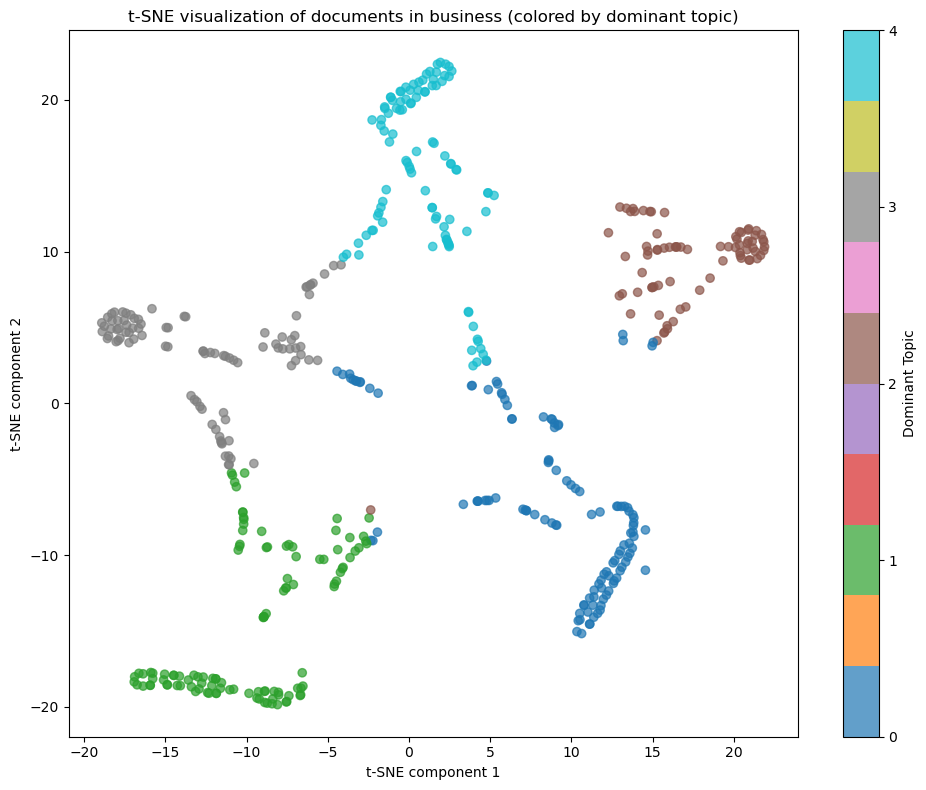

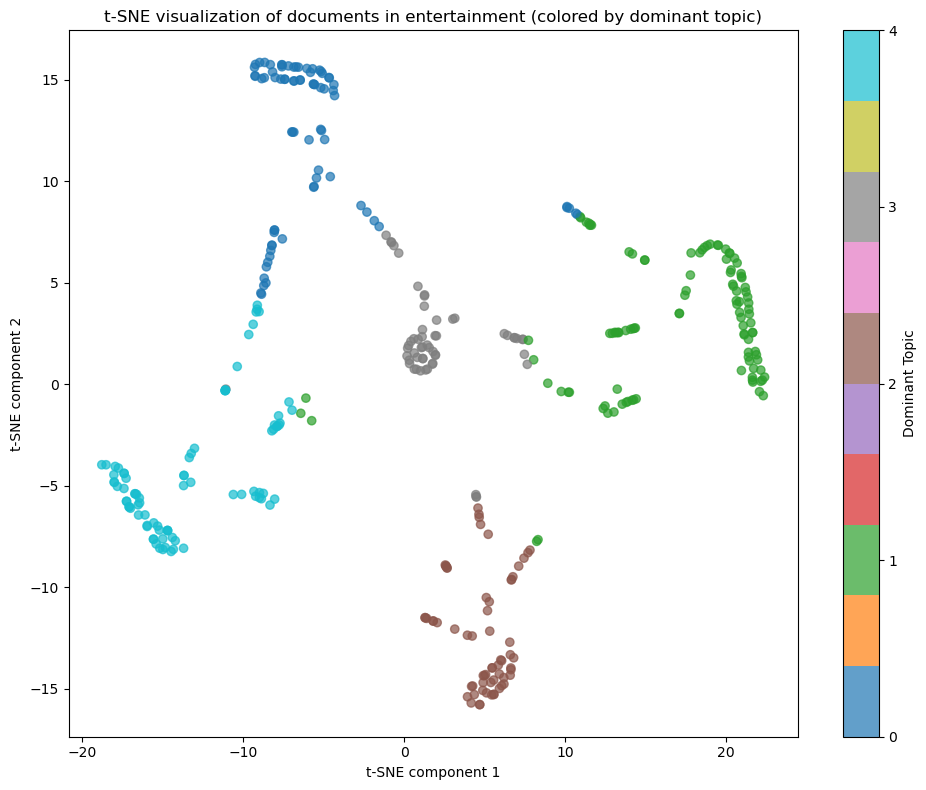

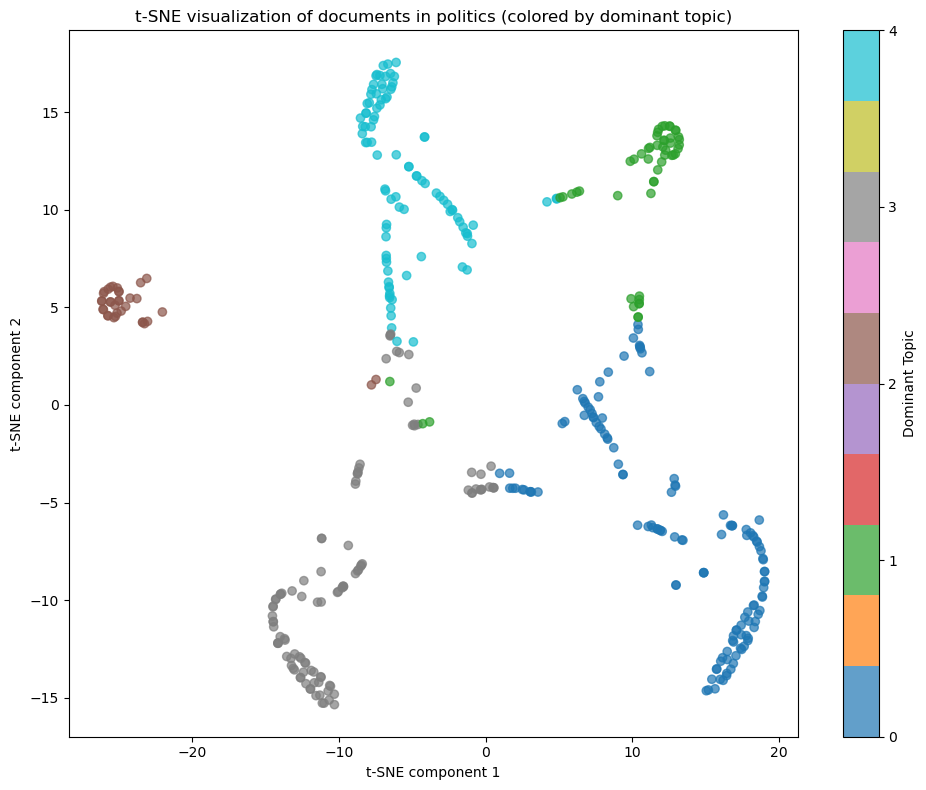

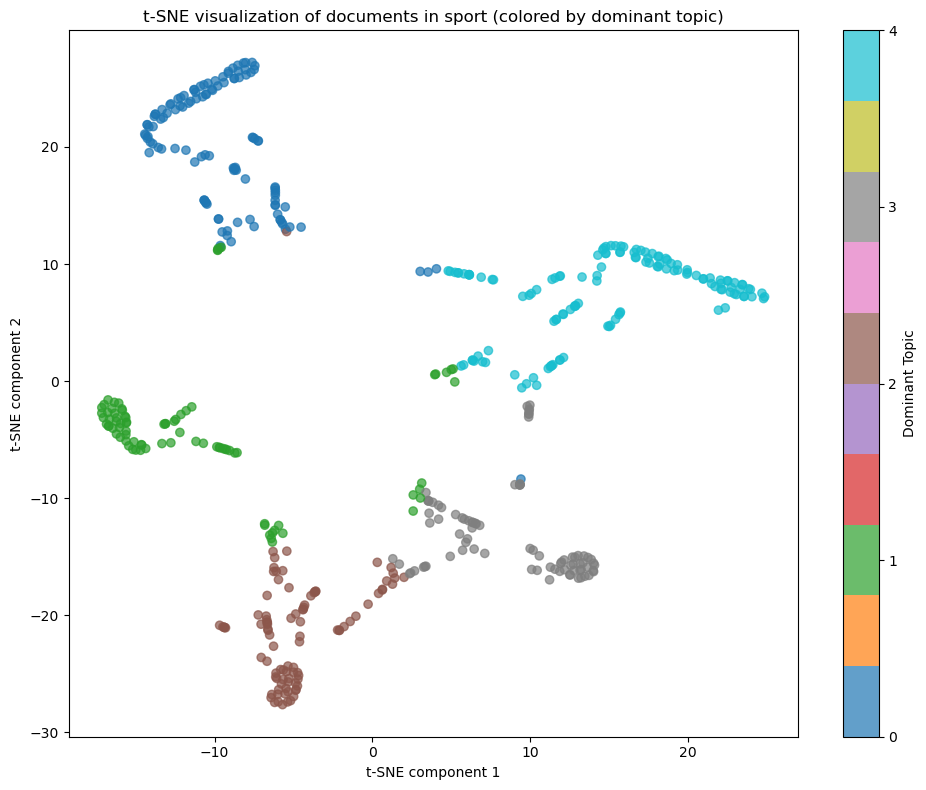

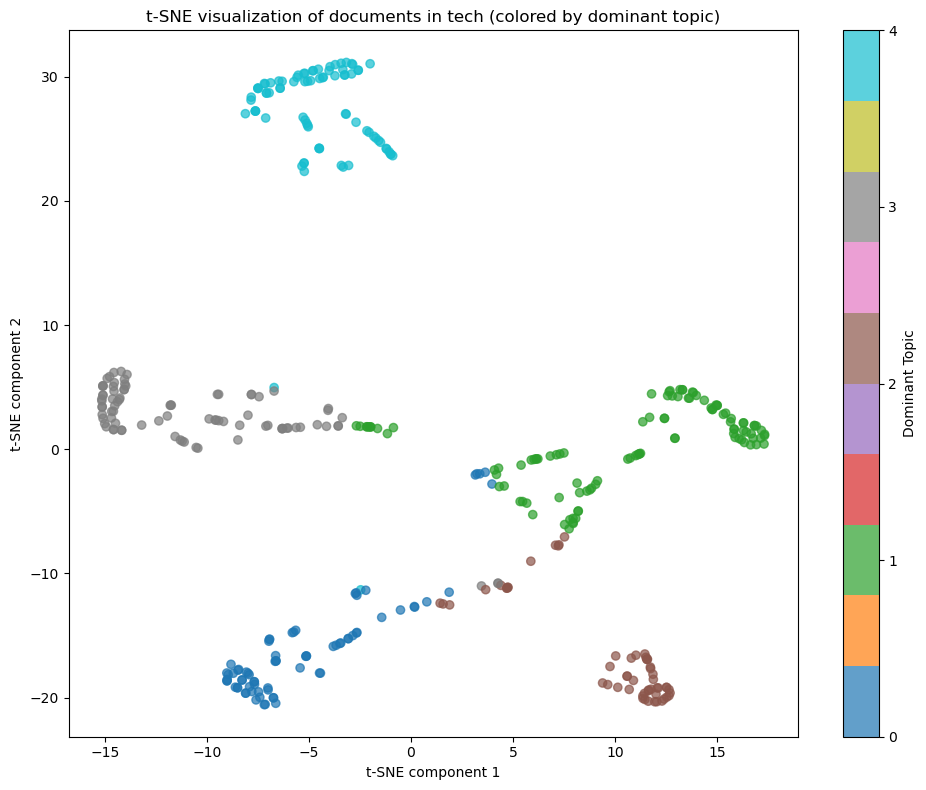

In [ ]:
#t-SNE визуализация для распределения тем каждой категории
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Для каждой категории вычисляем матрицу распределения документов по темам и применяем t-SNE.
for cat, res in results.items():
    model = res['model']
    corpus = res['corpus']
    num_topics = model.num_topics

    # Создайте матрицу «документ-тема» (каждая строка = распределение по темам).
    doc_topic_matrix = []
    dominant_topics = []
    for doc in corpus:
        # Получаем распределение тем для документа
        topic_dist = model.get_document_topics(doc, minimum_probability=0)
        # Преобразовываем в плотный вектор длиной num_topics.
        vec = np.zeros(num_topics)
        for topic_id, prob in topic_dist:
            vec[topic_id] = prob
        doc_topic_matrix.append(vec)
        dominant_topics.append(np.argmax(vec))

    doc_topic_matrix = np.array(doc_topic_matrix)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    doc_tsne = tsne.fit_transform(doc_topic_matrix)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(doc_tsne[:, 0], doc_tsne[:, 1],
                          c=dominant_topics, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, ticks=range(num_topics), label='Dominant Topic')
    plt.title(f't-SNE visualization of documents in {cat} (colored by dominant topic)')
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')
    plt.tight_layout()
    plt.savefig(f'tsne_{cat}.png')
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
import random

all_vectors = []      # Распределения тем LDA
all_texts = []        # оригинальный текст новости
all_categories = []   # метка категории
all_indices = []      # исходный указатель (необязательно)

# Используем исходные тексты из corpus_by_cat.
for cat in categories:
    docs = corpus_by_cat[cat]
    processed = processed_corpus[cat]
    # Модель LDA для категории
    lda_model = results[cat]['model']
    # Получаем корпус для категории.
    corpus_bow = results[cat]['corpus']

    for idx, bow in enumerate(corpus_bow):
        # Получаем распределение по темам
        topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
        vec = np.zeros(lda_model.num_topics)
        for tid, prob in topic_dist:
            vec[tid] = prob
        all_vectors.append(vec)
        all_texts.append(docs[idx])
        all_categories.append(cat)

all_vectors = np.array(all_vectors)

# Применяем t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(all_vectors)

# Для заданного документа (например, первого документа категории «спорт»), находим его ближайших соседей в пространстве t-SNE и отображаем их тексты.
doc_idx = 0
print(f"Selected document (category: {all_categories[doc_idx]}):\n")
print(all_texts[doc_idx][:500] + "...\n")
print("="*80)
print("Most similar documents (by Euclidean distance in t‑SNE space):\n")

# Вычисляем расстояния от выбранного документа до всех остальных.
distances = cdist([coords[doc_idx]], coords, metric='euclidean')[0]
# Получаем индексы 5 ближайших документов (исключая сам документ).
neighbors = np.argsort(distances)[1:6]

for i, n_idx in enumerate(neighbors, 1):
    print(f"{i}. Category: {all_categories[n_idx]}")
    print(all_texts[n_idx][:500] + "...\n")
    print("-"*80)

Selected document (category: business):

Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time W...

Most similar documents (by Euclidean distance in t‑SNE space):

1. Category: sport
Jones medals 'must go if guilty'

World Anti-Doping Agency (WADA) chief Dick Pound says Marion Jones should be stripped of all her medals if found guilty of taking banned substances.

Victor Conte, of Balco Laboratories, claims the American sprinter regularly used drugs to enhance her performance. "If she is found guilty she should be stripped of all her medals and ban

In [ ]:
# Ячейка с анализом тем по категориям
print("-"*80)
print("АНАЛИЗ ТЕМ ПО КАТЕГОРИЯМ НОВОСТЕЙ")
print("-"*80)

# Выведем ранее полученные темы для удобства (повторяем из последней ячейки)
for cat, res in results.items():
    lda = res['model']
    print(f"\n===== {cat.upper()} =====")
    topics = lda.print_topics(num_words=10)
    for idx, topic in topics:
        print(f"Topic {idx+1}: {topic}")

--------------------------------------------------------------------------------
АНАЛИЗ ТЕМ ПО КАТЕГОРИЯМ НОВОСТЕЙ
--------------------------------------------------------------------------------

===== BUSINESS =====
Topic 1: 0.012*"firm" + 0.009*"share" + 0.008*"market" + 0.006*"business" + 0.006*"executive" + 0.005*"stock" + 0.005*"financial" + 0.005*"chief" + 0.005*"bank" + 0.005*"new"
Topic 2: 0.014*"rate" + 0.013*"growth" + 0.012*"sale" + 0.011*"economy" + 0.008*"price" + 0.008*"month" + 0.008*"figure" + 0.008*"rise" + 0.008*"market" + 0.007*"bank"
Topic 3: 0.013*"yukos" + 0.010*"oil" + 0.007*"firm" + 0.007*"russian" + 0.006*"sale" + 0.006*"court" + 0.006*"tax" + 0.006*"price" + 0.005*"gazprom" + 0.004*"bankruptcy"
Topic 4: 0.009*"dollar" + 0.008*"country" + 0.008*"euro" + 0.007*"economy" + 0.007*"new" + 0.006*"economic" + 0.006*"market" + 0.005*"trade" + 0.005*"growth" + 0.005*"japan"
Topic 5: 0.009*"government" + 0.007*"firm" + 0.007*"country" + 0.006*"india" + 0.005*"investmen

## Анализ тематик по категориям новостей BBC

На основе обученных моделей LDA (по 5 тем на категорию) и ключевых слов, наиболее вероятных для каждой темы, можно сделать следующие выводы о содержании каждого класса.

---

### 1. Business (Бизнес)

- **Тема 1** (ключевые слова: *firm, share, market, business, executive, stock, financial, chief, bank, new*) – описывает корпоративную сферу: акции, финансовые показатели, руководство компаний, банки.
- **Тема 2** (*rate, growth, sale, economy, price, month, figure, rise, market, bank*) – макроэкономические показатели: рост, продажи, ставки, цены, инфляция.
- **Тема 3** (*yukos, oil, firm, russian, sale, court, tax, price, gazprom, bankruptcy*) – связана с нефтяной отраслью, судебными разбирательствами, налогами.
- **Тема 4** (*dollar, country, euro, economy, new, economic, market, trade, growth, japan*) – международная экономика, валюты (доллар, евро), торговля, Япония.
- **Тема 5** (*government, firm, country, india, investment, bank, new, deal, club, minister*) – государственное регулирование, инвестиции, сделки, министры, Индия.

**Вывод:** В бизнес-новостях преобладают темы корпоративных финансов (акции, банки), макроэкономики и международной торговли. Отдельно выделяется нефтяная тематика и судебные тяжбы крупных компаний.

---

### 2. Entertainment (Развлечения)

- **Тема 1** (*award, best, band, album, music, rock, top, song, first, new*) – музыкальные награды, альбомы, рок-музыка.
- **Тема 2** (*show, new, number, album, book, star, two, bbc, first, series*) – телешоу, книги, сериалы, звёзды, BBC.
- **Тема 3** (*star, best, actor, show, actress, award, role, movie, new, director*) – киноиндустрия: актёры, режиссёры, роли, награды.
- **Тема 4** (*music, song, best, show, people, last, would, urban, british, like*) – популярная музыка, британская сцена, песни.
- **Тема 5** (*best, award, director, oscar, festival, actor, chart, aviator, number, box*) – кинопремии (Оскар), фестивали, бокс-офис, фильм «Авиатор».

**Вывод:** В категории развлечений доминируют темы музыки (альбомы, награды, рок) и кино (актёры, режиссёры, Оскар). Также присутствуют темы телевидения и книг. Наиболее яркие сущности: Оскар, музыкальные чарты, британские исполнители.

---

### 3. Politics (Политика)

- **Тема 1** (*tax, tory, election, party, brown, howard, blair, plan, chancellor, britain*) – предвыборная борьба, налоги, партии (тори), лидеры (Браун, Блэр, Говард), канцлер.
- **Тема 2** (*lord, blair, right, election, wage, new, could, minimum, day, increase*) – права, минимальная зарплата, лорды, выборы, Блэр.
- **Тема 3** (*hunting, hunt, law, ban, police, bbc, campbell, new, tory, told*) – охота, запреты, законы, полиция, скандалы (Кэмпбелл).
- **Тема 4** (*lord, law, home, could, secretary, plan, police, new, public, right*) – внутренние дела, закон, министры, общественная безопасность.
- **Тема 5** (*party, election, blair, brown, told, ukip, prime, new, one, kilroysilk*) – партийная политика, выборы, премьер-министр, UKIP.

**Вывод:** Политические новости сосредоточены на выборах, партиях (тори, лейбористы), лидерах (Блэр, Браун). Важные темы – налоги, минимальная зарплата, закон об охоте, скандалы. Присутствует тема UKIP (евроскептики). Много упоминаний парламента и правительства.

---

### 4. Sport (Спорт)

- **Тема 1** (*england, wale, ireland, six, nation, france, side, try, player, rugby*) – регби, сборные Англии, Уэльса, Ирландии, Франции, турнир «Six Nations».
- **Тема 2** (*club, would, player, year, test, want, also, time, kenteris, get*) – общие спортивные темы: клубы, игроки, тесты, время.
- **Тема 3** (*world, race, year, win, new, european, second, time, best, olympic*) – мировые соревнования, Олимпийские игры, победы, рекорды.
- **Тема 4** (*chelsea, player, united, goal, league, arsenal, minute, side, cup, time*) – футбол: клубы (Челси, МЮ, Арсенал), голы, лиги, кубки.
- **Тема 5** (*win, open, match, year, first, set, last, world, play, cup*) – теннис и общие спортивные события: открытые чемпионаты, сеты, матчи, победы.

**Вывод:** Спортивные новости охватывают несколько видов спорта: регби (сборные, Six Nations), футбол (английские клубы, лиги), теннис (турниры «Большого шлема»), а также Олимпийские игры и лёгкую атлетику. Ярко выделяются темы футбольных клубов и регбийных сборных.

---

### 5. Tech (Технологии)

- **Тема 1** (*network, mobile, service, firm, site, net, system, first, use, make*) – сетевые технологии, мобильная связь, интернет-услуги.
- **Тема 2** (*mobile, phone, music, service, digital, player, video, device, camera, use*) – мобильные устройства, цифровая музыка, плееры, камеры.
- **Тема 3** (*broadband, user, net, site, search, computer, say, service, home, number*) – широкополосный доступ, поиск, компьютеры, домашний интернет.
- **Тема 4** (*security, virus, user, software, program, microsoft, system, computer, firm, blog*) – компьютерная безопасность, вирусы, ПО, Microsoft, блоги.
- **Тема 5** (*game, gaming, time, console, title, get, world, player, play, like*) – видеоигры, игровые консоли, игроки.

**Вывод:** Технологические новости группируются вокруг мобильной связи, интернета, цифровых устройств (плееры, камеры), компьютерной безопасности и видеоигр. Сильно выделяются темы «мобильные телефоны и музыка», «широкополосный доступ», «безопасность и вирусы», «игры и консоли». Присутствуют упоминания Microsoft и блогов.

---

## Общее заключение

Модели LDA успешно выделили содержательные темы, соответствующие ожидаемым категориям новостей. В бизнесе доминируют финансы и макроэкономика, в развлечениях – музыка и кино, в политике – выборы и партии, в спорте – регби, футбол и теннис, в технологиях – мобильные устройства, интернет, безопасность и игры. Полученные темы можно использовать для дальнейшего анализа, классификации или рекомендательных систем.